# 1 · Data and exploratory analysis
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/twillixa/california-housing-ml/blob/main/notebooks/01_data_and_eda.ipynb)

The California Housing dataset: one row per **census block group** from the 1990 U.S. Census
(Pace & Barry, 1997; Kaggle copy with the `ocean_proximity` column). The target is the block's
`median_house_value`. These are 1990 prices, so the project benchmarks models and drivers, not today's market.

In [1]:
import sys, os
if "google.colab" in sys.modules:  # running on Colab: fetch the repo first
    !git clone -q https://github.com/twillixa/california-housing-ml
    %cd california-housing-ml/notebooks
sys.path.insert(0, os.path.abspath("../src"))

import warnings
os.environ["PYTHONWARNINGS"] = "ignore"  # parallel CV workers don't inherit warnings filters
warnings.filterwarnings("ignore", message=".*encountered in matmul")  # spurious on macOS Accelerate
warnings.filterwarnings("ignore", category=UserWarning)
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
from housing import plots
plots.use_style()
pd.set_option("display.precision", 4)
pd.set_option("display.width", 160)
from housing.data import load_raw, filter_rows, Cleaner, clean, CAPPED_COLS, NUM_FEATURES

## Cleaning (report section "Data Cleaning and Feature Engineering")
1. Drop blocks at the **$500,001 price ceiling**: the census topcodes them, so their true value is unknown.
2. Drop the 5 **ISLAND** blocks, too rare to learn from.
3. Impute the 207 missing `total_bedrooms` with the median.
4. Add three ratios: rooms per household, bedrooms per room, people per household.
5. Cap the four block totals at their 99th percentile.

In [2]:
raw = load_raw()
rows = filter_rows(raw)
cleaner = Cleaner().fit(rows)
df = clean()
print(f"raw {raw.shape} → removed {(raw.median_house_value >= 500_000).sum()} topcoded + "
      f"{(raw.ocean_proximity == 'ISLAND').sum()} ISLAND → cleaned {df.shape}")
print(f"bedrooms median {cleaner.bedrooms_median:.0f}; caps:", {c: round(v) for c, v in cleaner.caps.items()})
df.describe().T[["mean", "50%", "min", "max"]]

raw (20640, 10) → removed 992 topcoded + 5 ISLAND → cleaned (19643, 13)
bedrooms median 436; caps: {'total_rooms': 11211, 'total_bedrooms': 2241, 'population': 5866, 'households': 1994}


,mean,50%,min,max
longitude,-119.5627,-118.5000,-124.3500,-114.3100
latitude,35.6525,34.2700,32.5400,41.9500
housing_median_age,28.3695,28.0000,1.0000,52.0000
total_rooms,2571.2126,2111.0000,2.0000,11210.5800
total_bedrooms,530.9477,436.0000,2.0000,2241.4800
population,1419.3674,1180.0000,3.0000,5866.3800
households,493.8674,411.0000,2.0000,1993.6400
median_income,3.6766,3.4492,0.4999,15.0001
median_house_value,192007.3765,173600.0000,14999.0000,499100.0000
rooms_per_household,5.3616,5.1857,0.8462,132.5333


## Where the expensive blocks are

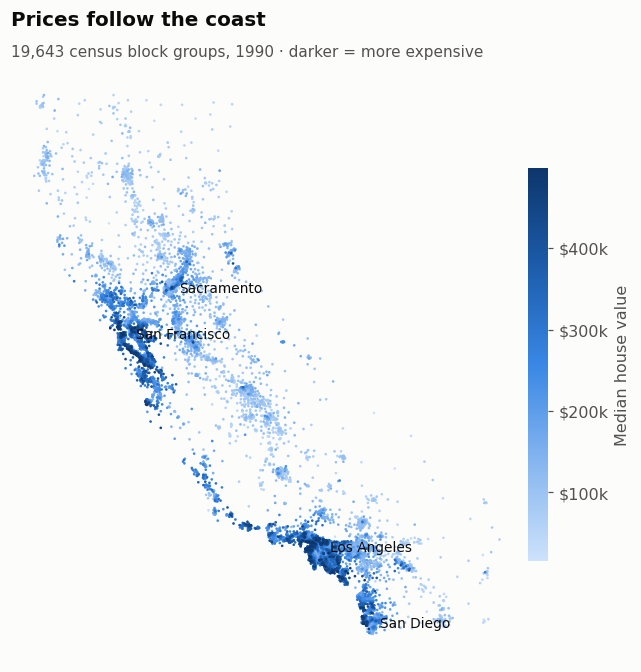

In [3]:
fig = plots.price_map(df); plots.save(fig, "price_map");

,count,50%,mean
ocean_proximity,,,
<1H OCEAN,8595.0,207400.0,223724.2001
INLAND,6523.0,108300.0,123194.8637
NEAR BAY,2088.0,219150.0,235917.6245
NEAR OCEAN,2437.0,217300.0,226711.2433


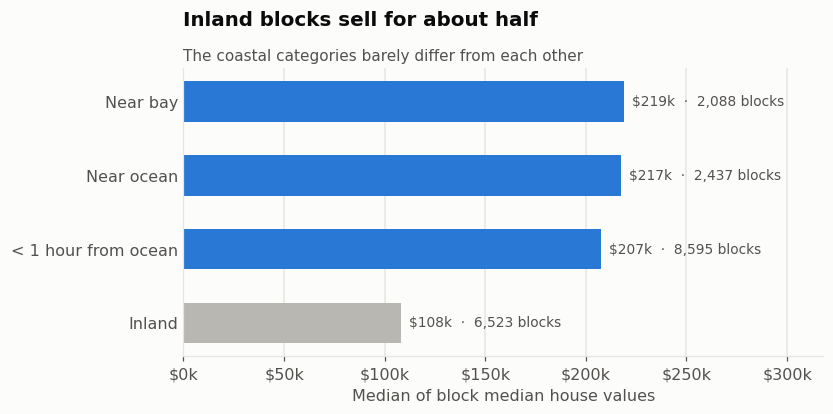

In [4]:
fig = plots.ocean_proximity(df); plots.save(fig, "ocean_proximity")
df.groupby("ocean_proximity")["median_house_value"].describe()[["count", "50%", "mean"]]

## What moves with price

bedrooms_per_room          -0.2002
population_per_household   -0.0212
population                  0.0130
housing_median_age          0.0646
total_bedrooms              0.0798
households                  0.1025
rooms_per_household         0.1116
total_rooms                 0.1600
median_income               0.6474
Name: median_house_value, dtype: float64

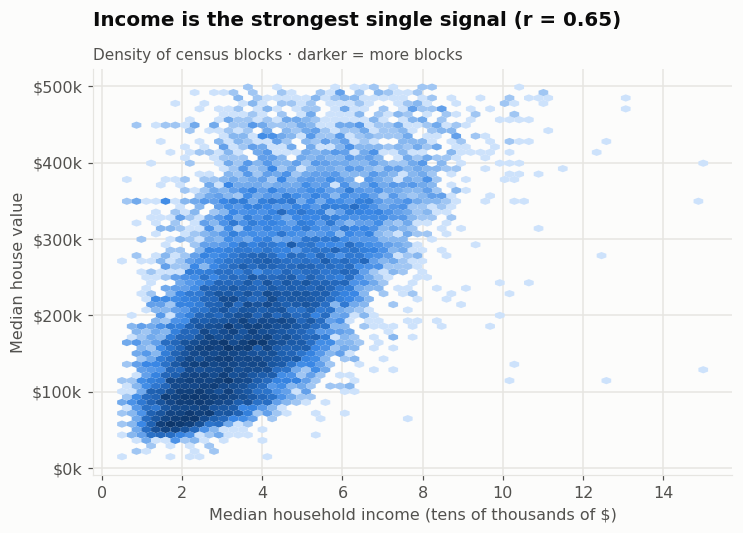

In [5]:
fig = plots.income_vs_value(df); plots.save(fig, "income_vs_value")
df[NUM_FEATURES + ["median_house_value"]].corr()["median_house_value"].drop("median_house_value").sort_values()

Income is the only feature with a strong linear correlation (r ≈ 0.65). Block totals (rooms, people,
households) mostly measure block *size* and are highly collinear with each other (r > 0.85), which is why the
ratio features were engineered. Location matters a lot (map, inland vs coast) but enters the report's models only
through the 4-level `ocean_proximity` category, not the coordinates. Notebook 3 tests that choice.